# Diffusion models

In [60]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll

## Implementing the original data

First, we are generating the data. Then we diffuse the model according to the paper.

### Generate data

In [83]:
def plot_data(data, alpha=0.1, color='b'):
    plt.scatter(data[:, 0], data[:, 1], alpha = 0.1, c=color)
    plt.xlim(-2, 2);
    plt.ylim(-2, 2);

In [62]:
def sample_batch(batch_size=10_000, device='cpu'):
    data, _ = make_swiss_roll(n_samples=batch_size)

    # Scale to have similar results as in paper
    data = data[:, [2, 0]] / 10 * np.array([1, -1])

    return torch.from_numpy(data).to(device)

In [63]:
data = sample_batch(10_000)

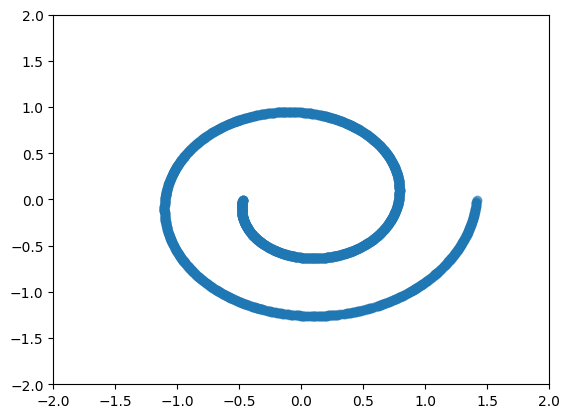

In [64]:
plot_data(data)

### Diffusion

Test two implementation for the forward pass (loop vs fast) and compare their times.

In [65]:
# Specify timesteps
T = 40

#### Generate the $\beta$'s

In [66]:
# Scaling the data, such that x_T looks like it was sampled from a Gaussian
betas = torch.sigmoid(torch.linspace(-18, 10, T)) * (3e-1  - 1e-5) + 1e-5

In [67]:
def slow_forward_process(data, T, betas):
    """
    Simulate the forward process of the diffusion model.

    Parameters
    ----------
    data : array-like, shape (n_samples, n_features)
        The input data.
    T : int
        The number of time steps.
    betas : array-like, shape (T,)
        The diffusion coefficients.

    Returns
    -------
    noisy_data : array-like, shape (n_samples, n_features)
        The noisy data after T time steps.
    """

    for t in range(T):

        # Add diffusion noise to data
        beta_t = betas[t]
        mu = data * torch.sqrt(1 - beta_t)
        std = torch.sqrt(beta_t)

        # Sample from q(x_t | x_{t-1})
        # data ~ N(mu, std)
        data = mu + torch.randn_like(data) * std
    return data

def fast_forward_process(data, T, betas):

    alphas = 1 - betas
    # alpha_bar = torch.cumprod(alphas, 0) # Returns a series
    alpha_bar_T = torch.prod(alphas, 0)

    mu = torch.sqrt(alpha_bar_T) * data
    sigma = torch.sqrt(1 - alpha_bar_T)
    epsilon = torch.randn_like(data)

    data = mu + epsilon * sigma
    return data

In [68]:
%%timeit
x_T = slow_forward_process(data, T, betas)

69.7 ms ± 9.35 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [69]:
%%timeit
x_T = fast_forward_process(data, T, betas)

1.56 ms ± 339 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


Visualize the results of the forward process. It should be look like it was sample from a Gaussian (mean and std. should match the ones of a normal distribution)

tensor([ 0.0123, -0.0099], dtype=torch.float64)
tensor([1.0058, 0.9904], dtype=torch.float64)


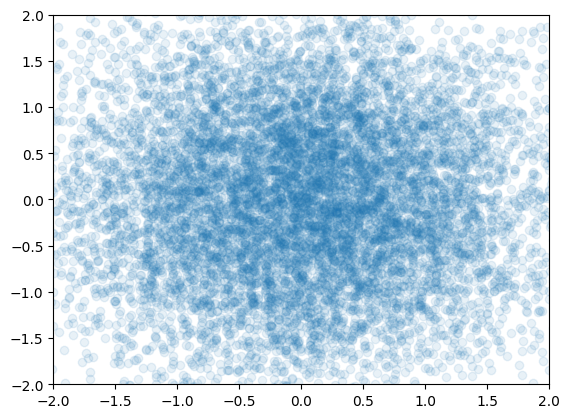

In [70]:
x_T = fast_forward_process(data, T, betas)
print(x_T.mean(0))
print(x_T.std(0))
plot_data(x_T.numpy())

Create a class that handles the work for us.

In [71]:
class DiffusionModel():

    @staticmethod
    def generate_betas(T: int):
        betas = torch.sigmoid(torch.linspace(-18, 10, T)) * (3e-1  - 1e-5) + 1e-5
        return betas

    def __init__(self, T:int):

        # Set timesteps
        self.T = T

        # Compute betas
        self.betas = DiffusionModel.generate_betas(self.T)

        # Compute alphas
        self.alphas = 1 - self.betas
        self.alphas_bar = torch.cumprod(self.alphas, dim=0)

    def forward_process(self, x_0, t=40):

        assert t > 0, 't should be greater than 0'
        assert t <= self.T, f't={t} should be smaller than T={self.T}'

        t = t - 1 # Because we start indexing at t = 0

        mu = torch.sqrt(self.alphas_bar[t]) * x_0
        std = torch.sqrt(1 - self.alphas_bar[t])
        epsilon = torch.randn_like(x_0)

        x_t = mu + epsilon * std

        return x_t

In [72]:
x_0 = sample_batch(10_000)
model = DiffusionModel(40)

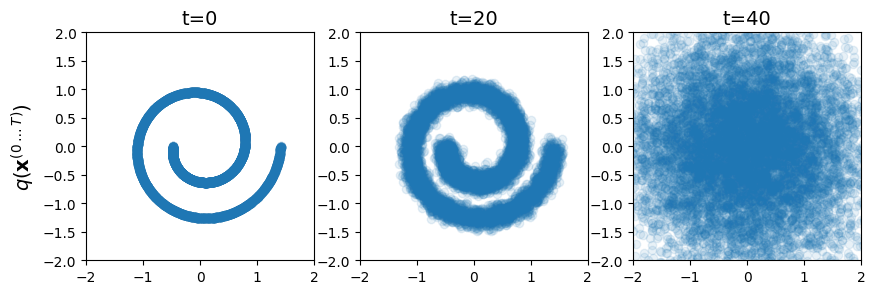

In [73]:
fontsize = 14
fig = plt.figure(figsize=(10, 3))


datas = [x_0, model.forward_process(x_0, 20), model.forward_process(x_0, 40)]
ts = [0, 20, 40]

for i in range(3):
    plt.subplot(1, 3, 1+i)
    plot_data(datas[i].numpy())
    plt.title(f't={ts[i]}', fontsize=fontsize)
    plt.gca().set_aspect('equal')

    if i == 0: plt.ylabel(r'$q(\mathbf{x}^{(0 \dots T)})$', fontsize=fontsize)

# plt.savefig('forward_process.png', bbox_inches='tight')

### Reverse diffusion

In [74]:
class MLP(nn.Module):
    def __init__(self, N:int=40, data_dim:int=2, hidden_dim:int=64):
        super(MLP, self).__init__()

        self.N = N
        self.data_dim = data_dim
        self.hidden_dim = hidden_dim

        self.network_head = nn.Sequential(
            nn.Linear(data_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.network_tail = nn.ModuleList(
            [
                nn.Sequential(
                    nn.Linear(hidden_dim, hidden_dim),
                    nn.ReLU(),
                    nn.Linear(hidden_dim, data_dim * 2),
                    nn.ReLU(),
                )
                for t in range(N)
            ]
        ) # * 2, because we need mean and covariance

    def forward(self, x:torch.tensor, t:int):

        # assert t > 0, 't should be greater than 0'

        h = self.network_head(x)        # [batch_size, hidden_dim]
        tmp = self.network_tail[t](h)   # [batch_size, data_dim * 2]

        mu, h = torch.chunk(tmp, chunks=2, dim=1) # [batch_size, data_dim], [batch_size, data_dim]

        var = torch.exp(h)
        std = torch.sqrt(var)

        return mu, std

In [75]:
model = MLP()
t = 5
x = torch.randn(10, 2)
mu, std = model(x, t)
mu.shape, std.shape

(torch.Size([10, 2]), torch.Size([10, 2]))

In [76]:
class DiffusionModel():

    @staticmethod
    def generate_betas(T: int):
        betas = torch.sigmoid(torch.linspace(-18, 10, T)) * (3e-1  - 1e-5) + 1e-5
        return betas

    def __init__(self, T:int, model:nn.Module, dim:int=2):

        # Set timesteps
        self.T = T

        # Compute betas
        self.betas = DiffusionModel.generate_betas(self.T)

        # Compute alphas
        self.alphas = 1 - self.betas
        self.alphas_bar = torch.cumprod(self.alphas, dim=0)

        self.model = model

        self.dim = dim

    def forward_process(self, x_0:torch.tensor, t:int=40):

        assert t > 0, 't should be greater than 0'
        assert t <= self.T, f't={t} should be smaller than T={self.T}'

        t = t - 1 # Because we start indexing at t = 0

        mu = torch.sqrt(self.alphas_bar[t]) * x_0
        std = torch.sqrt(1 - self.alphas_bar[t])
        epsilon = torch.randn_like(x_0)

        x_t = mu + epsilon * std

        return x_t

    def reverse_process(self, x_T:torch.tensor, t:int):

        assert t > 0, 't should be greater than 0'
        assert self.T <= self.T, f't={t} should be smaller than T={self.T}'

        t = t - 1 # Because we start indexing at t = 0

        mu, std = self.model(x_T, t)
        epsilon = torch.randn_like(x_T)

        x_t = mu + epsilon * std

        return x_t

    def sample(self, batch_size):
        noise = torch.randn((batch_size, self.dim))
        x = noise

        samples = [x]

        for t in range(self.T, 0, -1):



            if not (t == 1): # posterior mode collapse
                x = self.reverse_process(x, t)
            samples.append(x)

        return samples

In [77]:
x_0 = sample_batch(10_000)
model = DiffusionModel(40, MLP())
x_T = model.forward_process(x_0, 20)
samples = model.sample(1_000)

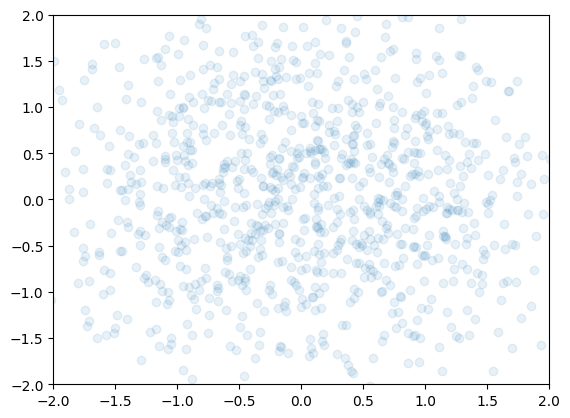

In [78]:
plot_data(samples[39].data.numpy())

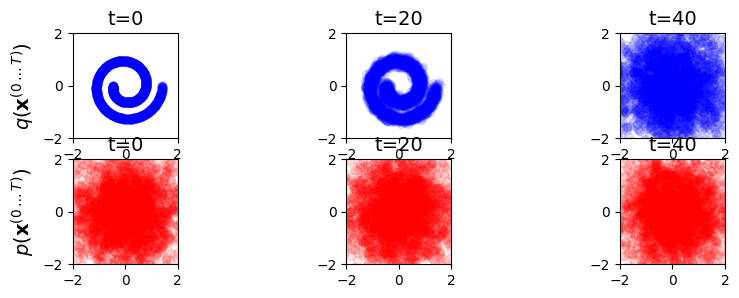

In [84]:
fontsize = 14
fig = plt.figure(figsize=(10, 3))

N = 3_000
x_0 = sample_batch(N)
forwards = [x_0, model.forward_process(x_0, 20), model.forward_process(x_0, 40)]
samples = model.sample(N)
time_steps = [0, 20, 40]

for i in range(3):
    plt.subplot(2, 3, 1+i)
    plot_data(forwards[i].numpy())
    plt.title(f't={ts[i]}', fontsize=fontsize)
    plt.gca().set_aspect('equal')

    if i == 0: plt.ylabel(r'$q(\mathbf{x}^{(0 \dots T)})$', fontsize=fontsize)

for i in range(3):
    plt.subplot(2, 3, 4+i)
    plot_data(samples[time_steps[i]].data.numpy(), color='r')
    plt.title(f't={ts[i]}', fontsize=fontsize)
    plt.gca().set_aspect('equal')

    if i == 0: plt.ylabel(r'$p(\mathbf{x}^{(0 \dots T)})$', fontsize=fontsize)

# plt.savefig('diffusion_model_paper1.png', bbox_inches='tight')

### Training the model

In the previous parts, we have only focused on implementing the forward and the reverse process. Next, the focus is on training the model.

$$
\mathbb{E}_{x^{(0)} \sim \mathcal{D}_\text{train}} \log p(x^{(0)})
$$